# IMPORT

In [1]:
import idx2numpy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
import time
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from umap import UMAP

/home/apkin/school21/projects/ML6_Unsupervised_learning_ID_1254805-1/src/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# LOAD DATA and PREPROCESS

load data from [kaggle]("https://www.kaggle.com/datasets/hojjatk/mnist-dataset")

In [2]:
X = idx2numpy.convert_from_file("./data/MNIST/train-images-idx3-ubyte")
y = idx2numpy.convert_from_file("./data/MNIST/train-labels-idx1-ubyte")

example of data

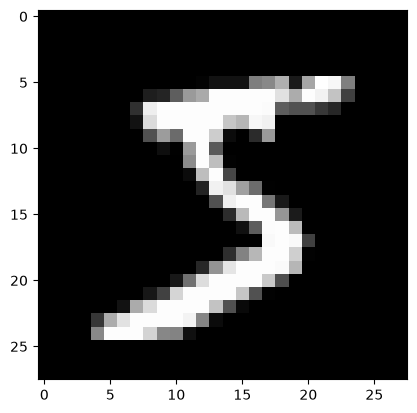

In [3]:
plt.imshow(X[0], cmap='gray')
plt.show()

Choosing examples for task

In [4]:
X, _, y, _ = train_test_split(
    X, y,
    train_size=10000,
    stratify=y,
    random_state=21
)

Represent each digit image as a vector.

In [5]:
X = X.reshape(X.shape[0], -1)
X.shape

(10000, 784)

# Transform vectors up to 2 dimensions

In [6]:
def evaluate_decomposition(method, method_name, X, y):
    start = time.perf_counter()

    X_reduced = method.fit_transform(X)

    fit_time = time.perf_counter() - start

    silhouette = silhouette_score(X_reduced, y)

    knn = KNeighborsClassifier(n_neighbors=5)

    knn_accuracy = cross_val_score(
        knn,
        X_reduced, y,
        cv=5,
    ).mean()

    plt.figure(figsize=(15,10))

    scatter = plt.scatter(
        X_reduced[:, 0],
        X_reduced[:, 1],
        c=y,
        cmap="tab10",
        s=10
    )

    plt.xlabel("Component1")
    plt.ylabel("Component2")
    plt.title(f"dim.reduction - {method_name}")
    plt.colorbar(
        scatter,
        ticks=range(10),
        label='Digit'
    )
    plt.show()

    result = {
        "Method": method_name,
        "Time (s)": fit_time,
        "Silhouette": silhouette,
        "kNN Accuracy": knn_accuracy
    }

    return X_reduced, result

In [7]:
table = pd.DataFrame(
    columns=[
        "Method",
        "Time (s)",
        "Silhouette",
        "kNN Accuracy"
    ]
)

def save_results(table, results):
    table.loc[len(table)] = results

### Using PCA

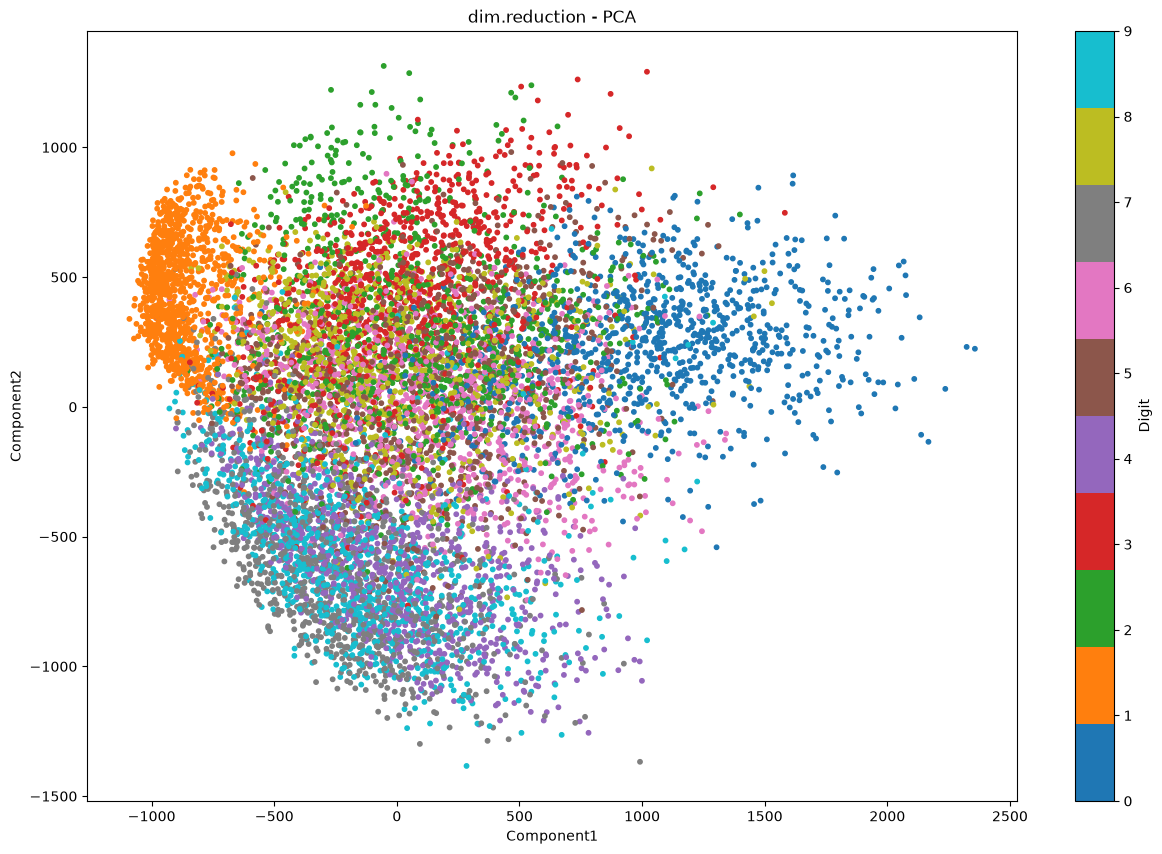

In [8]:
pca = PCA(n_components=2)

X_pca, pca_results = evaluate_decomposition(
    pca,
    "PCA",
    X, y
)

save_results(table, pca_results)

### Using SVD

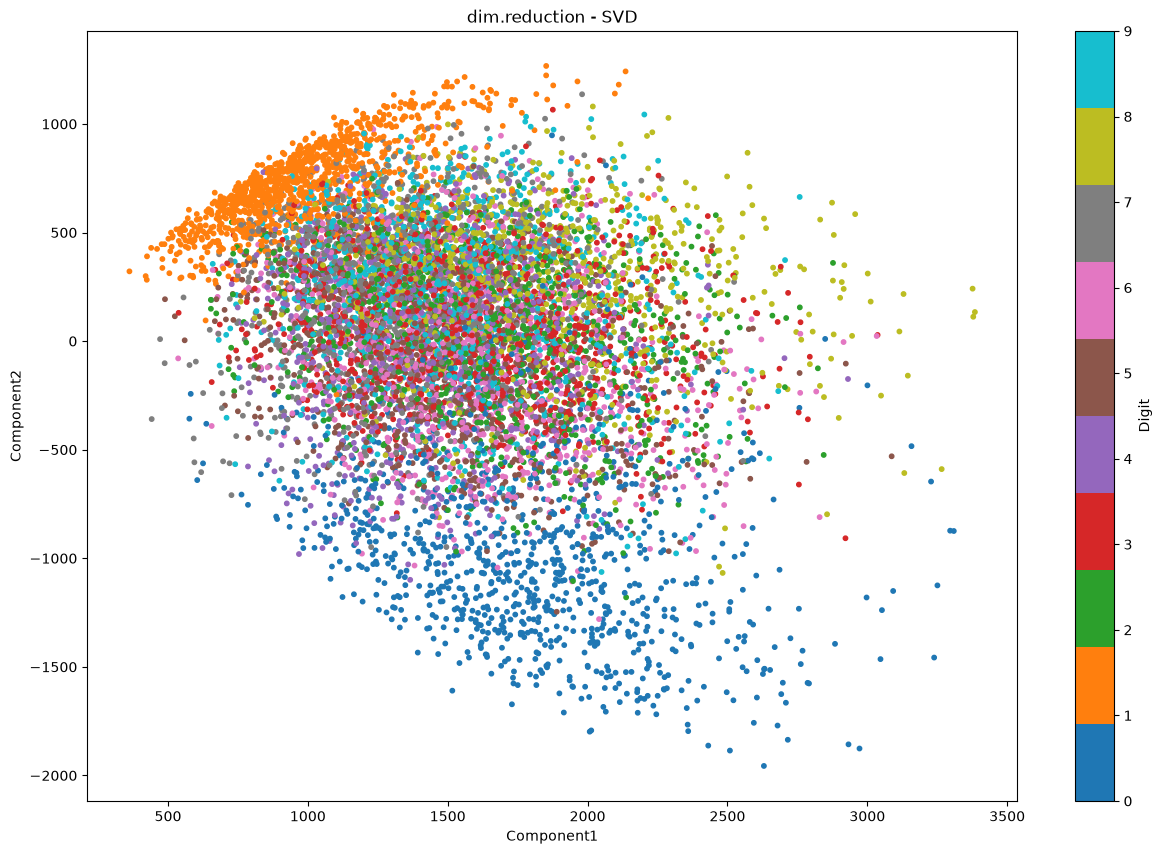

In [9]:
svd = TruncatedSVD(
    n_components=2,
    random_state=21
)

X_svd, svd_result = evaluate_decomposition(
    svd,
    "SVD",
    X, y
)

save_results(table, svd_result)

### Using Randomized-SVD

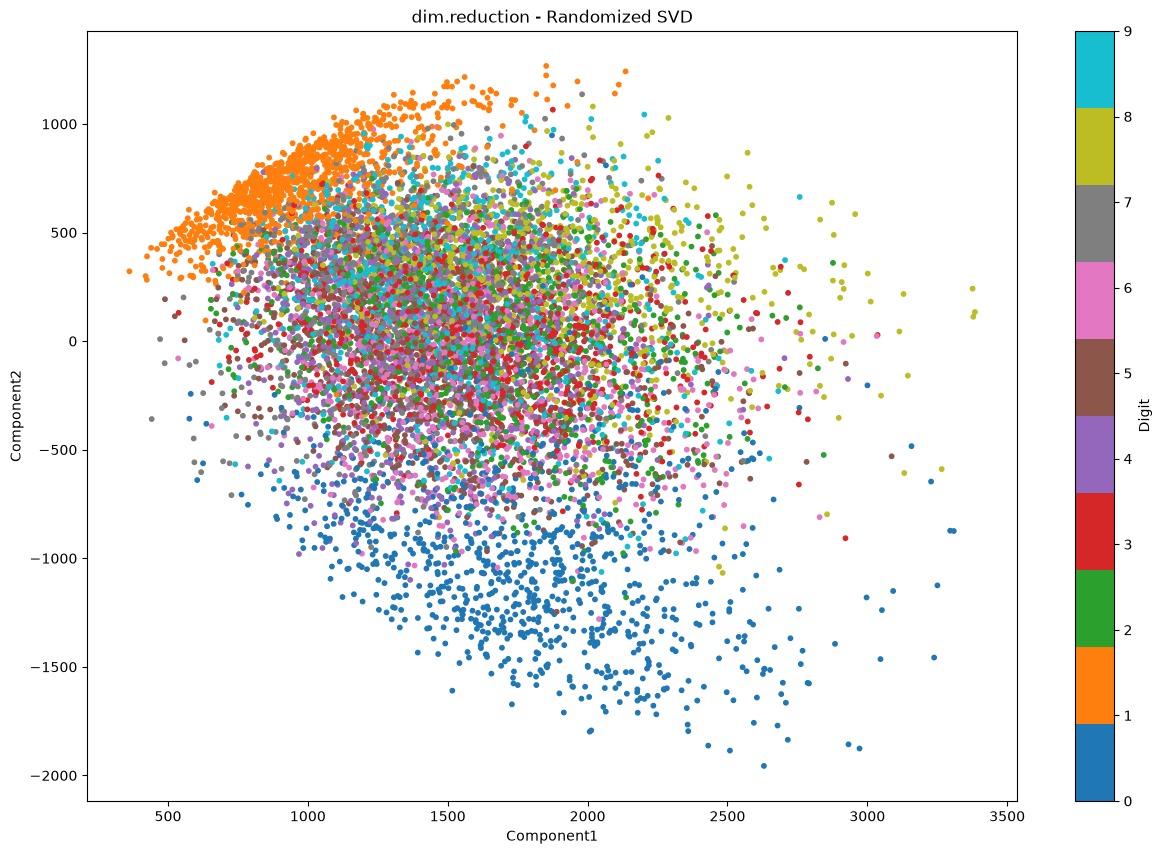

In [10]:
randomized_svd = TruncatedSVD(
    n_components=2,
    algorithm='randomized',
    random_state=21
)

X_randomized_svd, randomized_svd_result = evaluate_decomposition(
    randomized_svd,
    "Randomized SVD",
    X, y
)

save_results(table, randomized_svd_result)

### Using t-SNE

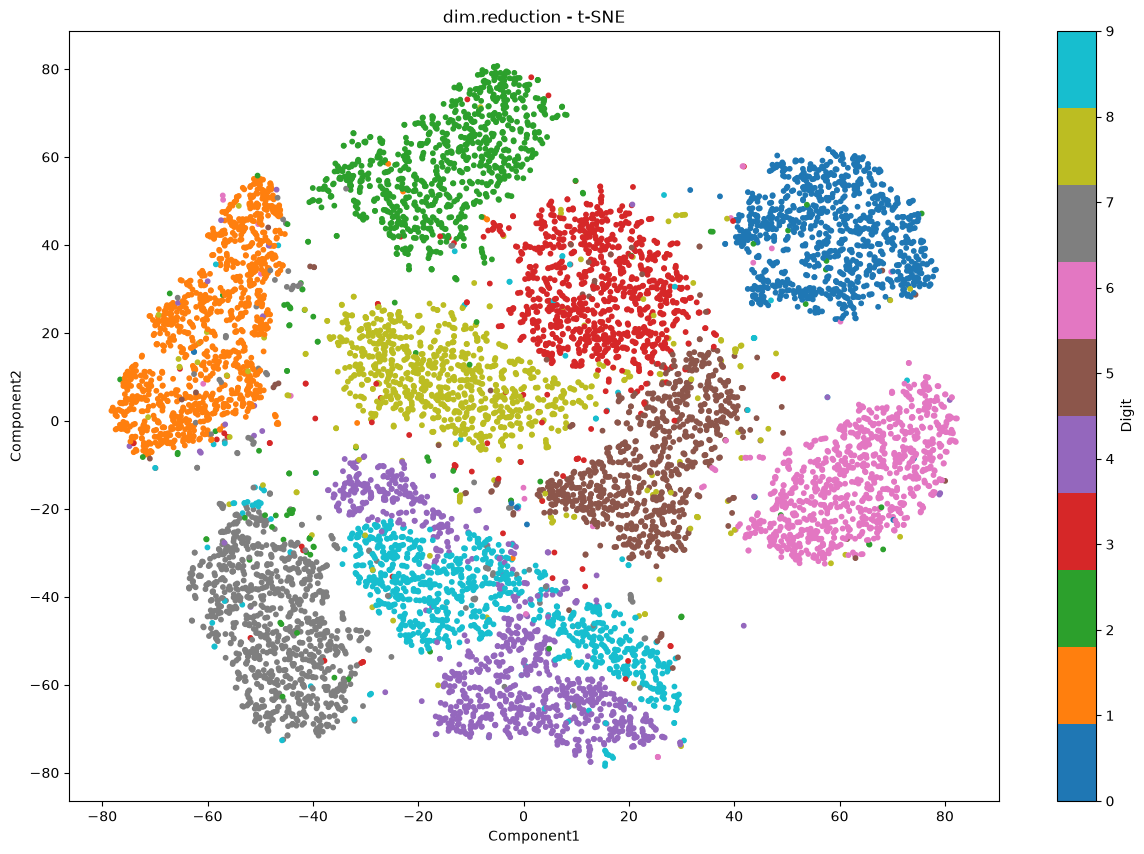

In [11]:
tsne = TSNE(
    n_components=2,
    random_state=21
)

X_tsne, tsne_result = evaluate_decomposition(
    tsne,
    "t-SNE",
    X, y
)

save_results(table, tsne_result)

### Using UMAP

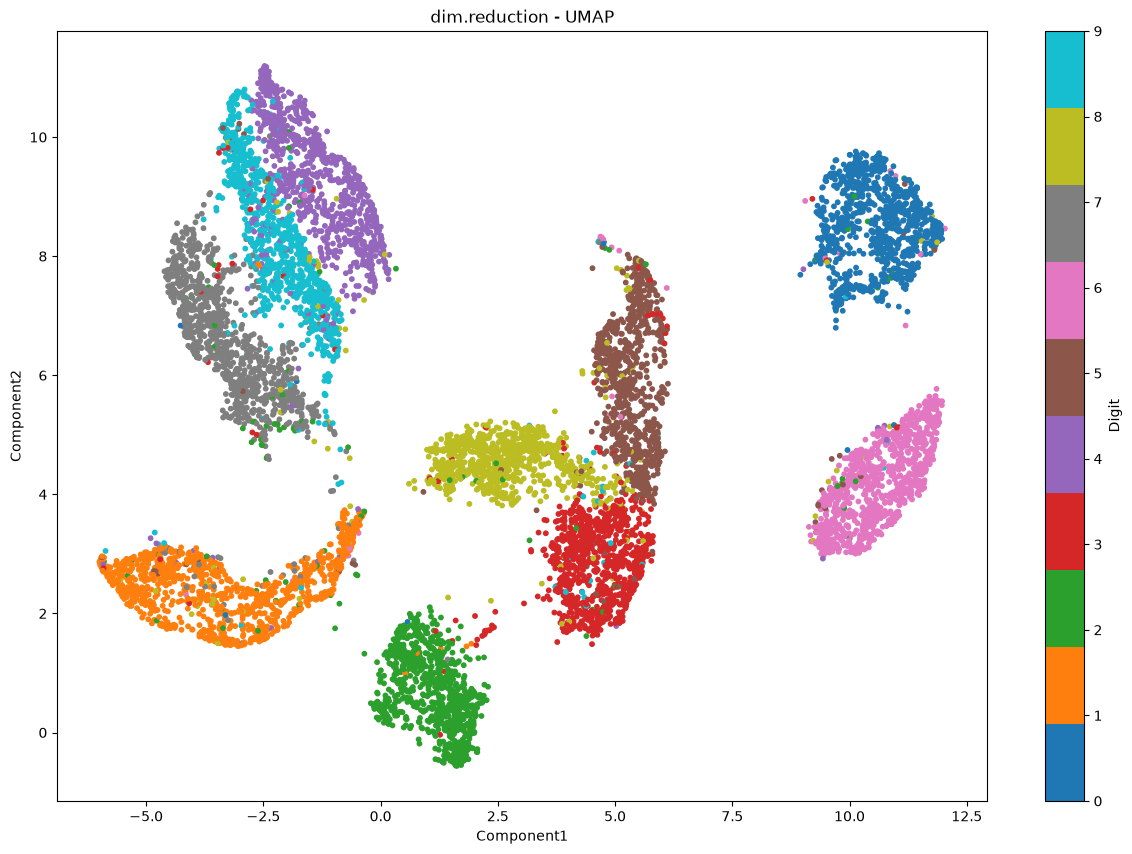

In [12]:
umap = UMAP(n_components=2,)

X_umap, umap_result = evaluate_decomposition(
    umap,
    "UMAP",
    X, y
)

save_results(table, umap_result)

### Using LLE

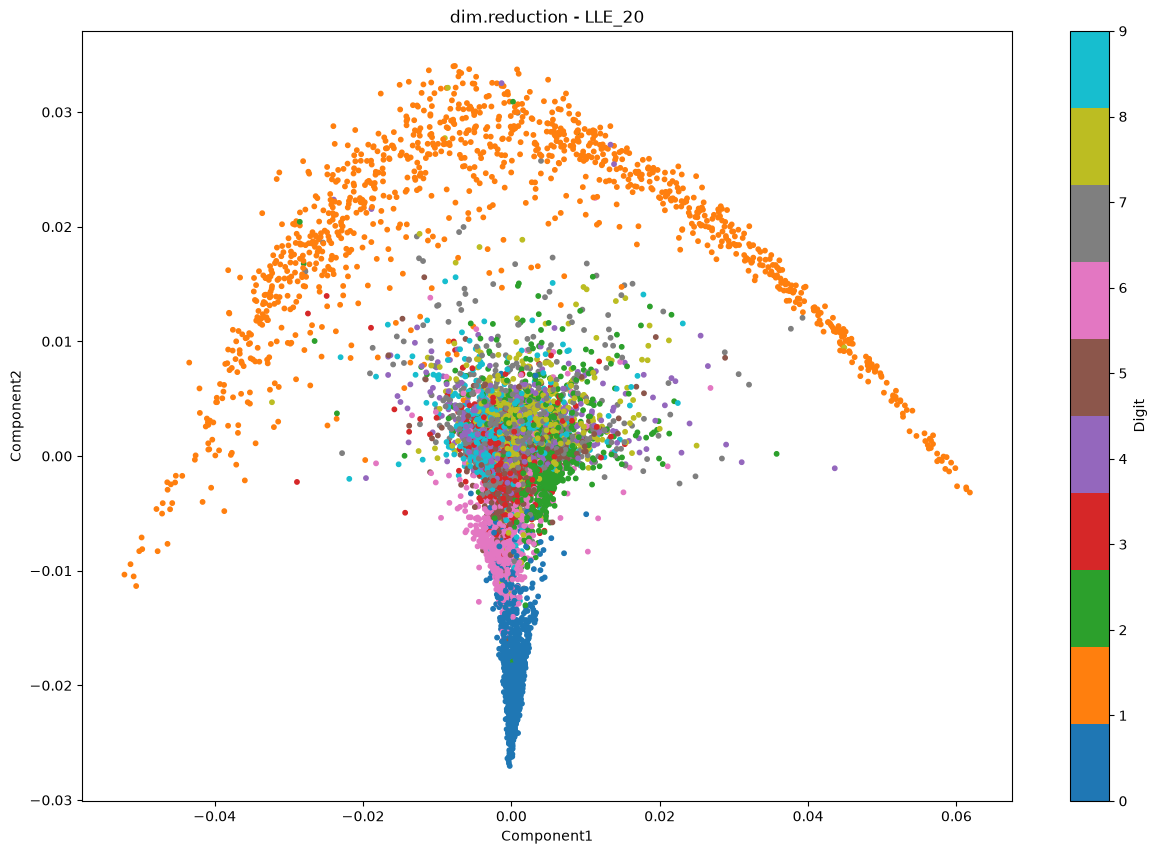

In [13]:
lle = LocallyLinearEmbedding(
    n_components=2,
    n_neighbors=20,
    random_state=21
)

X_lle, lle_result = evaluate_decomposition(
    lle,
    "LLE_20",
    X, y
)

save_results(table, lle_result)

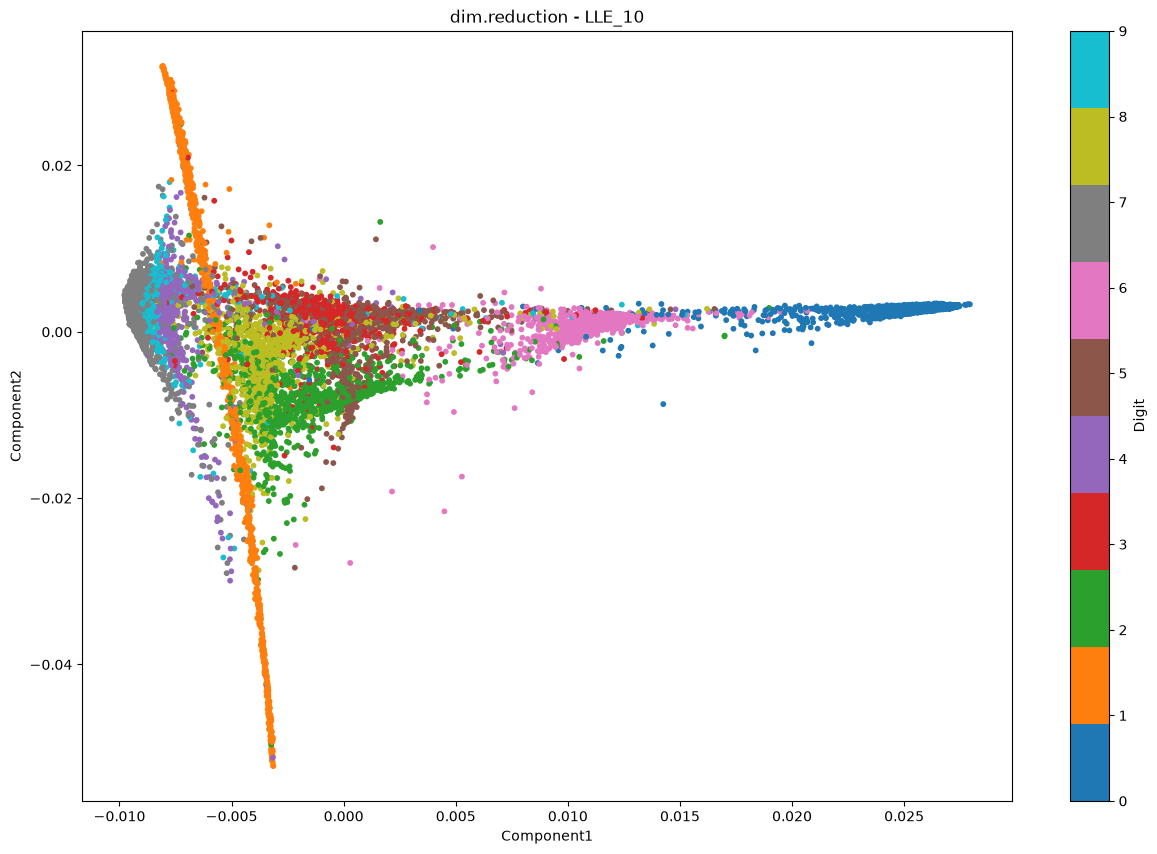

In [14]:
lle = LocallyLinearEmbedding(
    n_components=2,
    n_neighbors=10,
    random_state=21
)

X_lle, lle_result = evaluate_decomposition(
    lle,
    "LLE_10",
    X, y
)

save_results(table, lle_result)

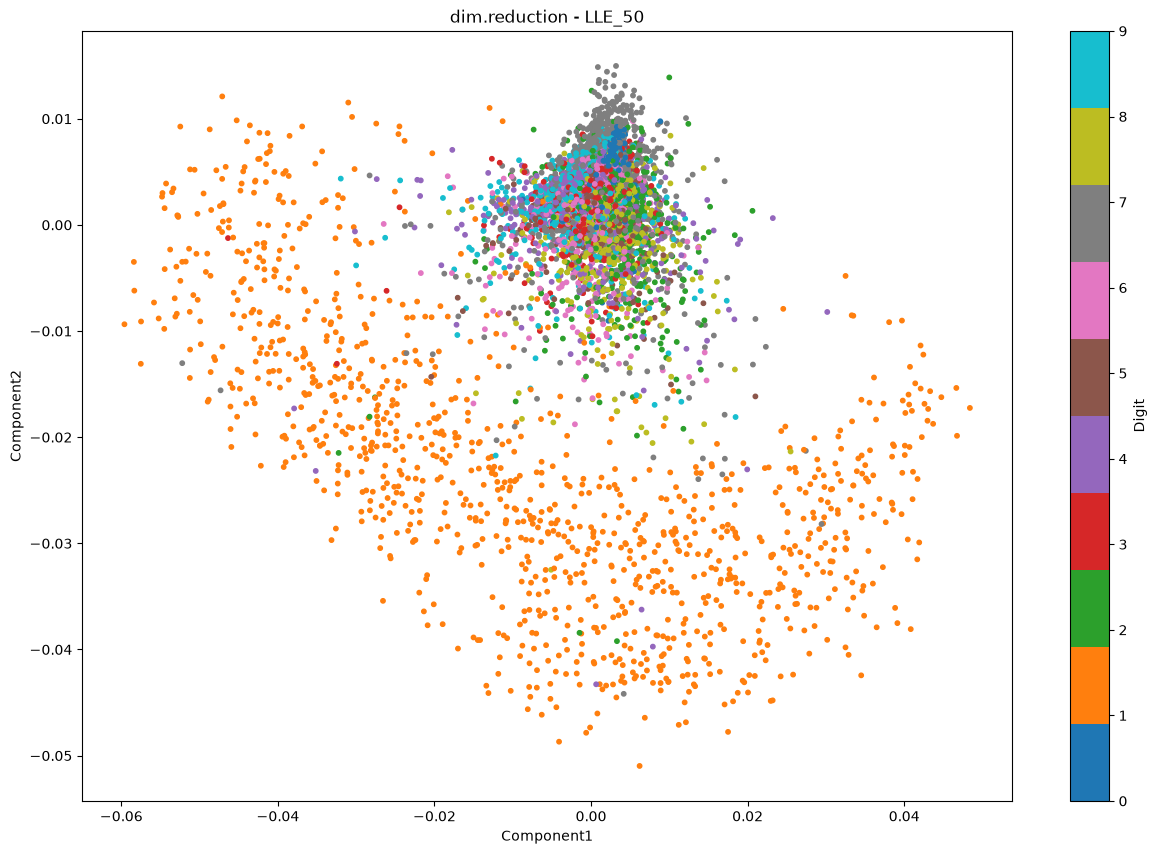

In [17]:
lle = LocallyLinearEmbedding(
    n_components=2,
    n_neighbors=50,
    random_state=21
)

X_lle, lle_result = evaluate_decomposition(
    lle,
    "LLE_50",
    X, y
)

save_results(table, lle_result)

# Metrics and results of dimensionality reduction

### Evaluation Metrics

To compare the quality of the 2D representations, **Silhouette Score** and **k-Nearest Neighbors (kNN) classification accuracy** are used.

#### 1. Silhouette Score

The Silhouette Score measures how well samples are separated into different classes. It considers both the distance between a sample and other samples from the same class and the distance to samples from the nearest different class.

For each sample $i$:

$$
s_i = \frac{b_i - a_i}{\max(a_i, b_i)}
$$

where:

- $a_i$ is the mean distance from sample $i$ to samples of the same class;
- $b_i$ is the smallest mean distance from sample $i$ to samples of any other class.

The final Silhouette Score is the mean value over all samples:

$$
S = \frac{1}{n}\sum_{i=1}^{n}s_i
$$

The score ranges from $-1$ to $1$. Higher values indicate better class separation. A value close to $1$ means that samples are close to their own class and far from other classes, while negative values indicate substantial overlap between classes.

#### 2. kNN Classification Accuracy

kNN accuracy evaluates how well the classes can be predicted using the 2D representation. For each sample, the algorithm finds its $k$ nearest neighbors and predicts the class based on the classes of these neighbors.

For $k=5$, the predicted class is determined from the five nearest points.

The accuracy is calculated as:

$$
\text{Accuracy} =
\frac{\text{Number of correctly classified samples}}
{\text{Total number of samples}}
$$

The value ranges from $0$ to $1$, with higher values indicating better class separation.

In this experiment, **5-fold cross-validation** is used to obtain a more reliable estimate of the kNN accuracy.

### Table of results

In [18]:
table

,Method,Time (s),Silhouette,kNN Accuracy
0,PCA,0.119391,0.020826,0.4050
1,SVD,0.478932,-0.026804,0.2975
2,Randomized SVD,0.575375,-0.026804,0.2975
3,t-SNE,13.664974,0.338798,0.9430
4,UMAP,16.055006,0.402298,0.9354
5,LLE_20,31.595804,-0.034650,0.4499
6,LLE_10,18.229109,0.067716,0.7440
7,LLE_50,41.450448,-0.145235,0.3423


Overall, t-SNE and UMAP provided the best 2D representations in terms of class separation. 
t-SNE achieved the highest kNN accuracy (0.943), while UMAP achieved the highest Silhouette Score (0.402). 
PCA was substantially faster than the nonlinear methods, but produced much weaker class separation. 
LLE showed a strong sensitivity to the number of neighbors: the best result was obtained with 10 neighbors, while increasing the neighborhood size to 20 or 50 significantly degraded the embedding quality.